# Cube-ID Encoding Demo

This notebook demonstrates the `cube-id` encoding mode implemented from `Docs/Encoding Method.md`.

The decoder formula is:

```text
CubeID = floor(B / 64) * 64 + floor(G / 32) * 8 + floor(R / 32)
```

`cube-id` is a direct quantization mapping: one byte is stored in one RGB pixel. It does not add error correction.

In [1]:
import json
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from PIL import Image

from diffusion_hash_inv.config import (
    Byte2RGBConfig,
    HashConfig,
    ImgConfig,
    MainConfig,
    MessageConfig,
    OutputConfig,
)
from diffusion_hash_inv.core import RGB
from diffusion_hash_inv.main import MainEP, RuntimeConfig
from diffusion_hash_inv.utils.byte2rgb import Byte2RGB

PROJECT_ROOT

PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse')

## Generate a hash run with cube-id configuration

This cell runs the project hash pipeline first. It generates one deterministic MD5 JSON trace for a 32-bit input and then writes PNG images from that JSON using `cube-id` encoding.

In [2]:
HASH_ALG = "md5"
BIT_LENGTH = 32
ITERATIONS = 1
RUN_PNG_ARTIFACTS = True

runtime_cfg = RuntimeConfig(
    main=MainConfig(
        verbose_flag=False,
        clean_flag=False,
        debug_flag=False,
        make_image_flag=RUN_PNG_ARTIFACTS,
        image_workers=1,
    ),
    message=MessageConfig(
        message_flag=False,
        length=BIT_LENGTH,
        random_flag=False,
        seed_flag=False,
        input_seed=0,
    ),
    hash=HashConfig(hash_alg=HASH_ALG, length=BIT_LENGTH),
    output=OutputConfig(root_dir=PROJECT_ROOT),
    rgb=Byte2RGBConfig(encoding="cube-id", seed_flag=False, input_seed=0),
)

entry_point = MainEP(runtime_cfg)
entry_point.run(
    iteration=ITERATIONS,
    run_hash_json=True,
    run_png=RUN_PNG_ARTIFACTS,
    run_hdf5=False,
)

encoder = Byte2RGB(runtime_cfg.main, runtime_cfg.hash, runtime_cfg.rgb)
print("encoding:", encoder.rgb_config.encoding)
print("pixels_per_byte:", encoder.pixels_per_byte)

Main Entry Point Initialized.
Program Start Time: 2026-05-22 15:26:03.410099+09:00
Hash Algorithm: MD5
Message Length: 32
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output
Hash Generation Progress: 0/1 iteration
Hash Generation Progress: 1/1 iteration Hash Algorithm=MD5 Message Length=32
Hash Generation Progress: done 1/1 iteration Hash Algorithm=MD5 Message Length=32
Hash Calculation time: 2 ms, 919 us, 42 ns
Hash/json generation completed.

RGB Image Maker Module Loaded.
RGB Image Maker Initialized.
Found 1 logs to process.
Expected 71 PNG files (71 images per log).
Processing Logs: 0/1 log
Writing Images: 0/71 image
Writing Images: 71/71 image
Processing Logs: 1/1 log
Processing Logs: 1/1 log images=71
Writing Images: done 71/71 image
Processing Logs: done 1/1 log images=71
Image writing completed: 71 images.
RGB Image Maker execution time: 147 ms, 407 us, 250 ns
RGB

## Inspect the generated hash JSON

In [3]:
latest_json_paths = entry_point.io_controller.get_latest_files_by_date(HASH_ALG, BIT_LENGTH)
assert latest_json_paths, "No generated JSON logs found."
latest_json_path = latest_json_paths[-1]

with latest_json_path.open("r", encoding="utf-8") as file:
    hash_log = json.load(file)

message_hex = hash_log["Message"]["Hex"]
generated_hash_hex = hash_log["Generated hash"]
correct_hash_hex = hash_log["Correct   hash"]

assert generated_hash_hex == correct_hash_hex

print("json:", latest_json_path)
print("message:", message_hex)
print("hash:", generated_hash_hex)

json: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json/2026-05-22 15-26-03.410099+09-00/MD5_32_2026-05-22 15-26-03.410099+09-00_0.json
message: 0x00000000
hash: 0xf1d3ff8443297732862df21dc4e57262


## Decode the generated `message.png` artifact

The pipeline stores one byte per `ImgConfig.img_size` block. For `cube-id`, the block center color is the encoded byte.

In [4]:
def hex_to_bytes(value: str) -> bytes:
    value = value.removeprefix("0x")
    return bytes.fromhex(value)


def sample_imgconfig_blocks(path: Path) -> tuple[RGB, ...]:
    block_width, block_height = ImgConfig().img_size
    with Image.open(path) as image:
        rgb_image = image.convert("RGB")
        width, height = rgb_image.size
        assert width % block_width == 0 and height % block_height == 0
        pixels = []
        for block_y in range(height // block_height):
            y = block_y * block_height + block_height // 2
            for block_x in range(width // block_width):
                x = block_x * block_width + block_width // 2
                pixels.append(RGB.from_tuple(rgb_image.getpixel((x, y))))
        return tuple(pixels)


image_dir = runtime_cfg.output.data_dir / "images" / latest_json_path.stem
message_png = image_dir / "message.png"
assert message_png.exists(), message_png

sampled_message_rgb = sample_imgconfig_blocks(message_png)
decoded_message = encoder.rgb_decoder(sampled_message_rgb)
assert decoded_message == hex_to_bytes(message_hex)

print("message image:", message_png)
print("decoded message:", decoded_message.hex())
Image.open(message_png)

message image: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images/MD5_32_2026-05-22 15-26-03.410099+09-00_0/message.png
decoded message: 00000000


## Encode the generated hash with cube-id

encoded hash image: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_generated_hash.png
decoded hash: f1d3ff8443297732862df21dc4e57262


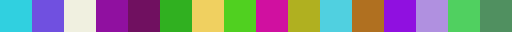

In [5]:
hash_bytes = hex_to_bytes(generated_hash_hex)
encoded_hash = encoder.rgb_encoder(hash_bytes)
hash_pixels = encoded_hash if isinstance(encoded_hash, tuple) else (encoded_hash,)

hash_image = Image.new("RGB", (len(hash_pixels), 1))
hash_image.putdata([pixel.as_tuple for pixel in hash_pixels])

output_dir = PROJECT_ROOT / "output"
output_dir.mkdir(exist_ok=True)
hash_image_path = output_dir / "cube_id_generated_hash.png"
hash_image.save(hash_image_path)

decoded_hash = encoder.rgb_decoder(hash_pixels)
assert decoded_hash == hash_bytes

print("encoded hash image:", hash_image_path)
print("decoded hash:", decoded_hash.hex())
hash_image.resize((len(hash_pixels) * 32, 32), Image.Resampling.NEAREST)

## Standalone cube-id encoder

In [6]:
main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=False,
    debug_flag=False,
    make_image_flag=False,
)
hash_cfg = HashConfig(hash_alg="md5", length=16)
rgb_cfg = Byte2RGBConfig(encoding="cube-id", seed_flag=False, input_seed=0)

encoder = Byte2RGB(main_cfg, hash_cfg, rgb_cfg)

print("encoding:", encoder.rgb_config.encoding)
print("pixels_per_byte:", encoder.pixels_per_byte)

encoding: cube-id
pixels_per_byte: 1


## Encode sample bytes

In [7]:
def cube_formula(rgb: RGB) -> int:
    return (rgb.b // 64) * 64 + (rgb.g // 32) * 8 + (rgb.r // 32)


sample_values = [0, 1, 7, 8, 63, 64, 73, 255]
sample_rows = []
for value in sample_values:
    rgb = encoder.rgb_encoder(bytes([value]))
    assert isinstance(rgb, RGB)
    decoded = encoder.rgb_decoder(rgb)
    sample_rows.append(
        {
            "byte_dec": value,
            "byte_hex": f"0x{value:02x}",
            "rgb": rgb.as_tuple,
            "cube_id": encoder.rgb_to_cube_id(rgb),
            "formula": cube_formula(rgb),
            "decoded_hex": decoded.hex(),
        }
    )

sample_rows

[{'byte_dec': 0,
  'byte_hex': '0x00',
  'rgb': (16, 16, 32),
  'cube_id': 0,
  'formula': 0,
  'decoded_hex': '00'},
 {'byte_dec': 1,
  'byte_hex': '0x01',
  'rgb': (48, 16, 32),
  'cube_id': 1,
  'formula': 1,
  'decoded_hex': '01'},
 {'byte_dec': 7,
  'byte_hex': '0x07',
  'rgb': (240, 16, 32),
  'cube_id': 7,
  'formula': 7,
  'decoded_hex': '07'},
 {'byte_dec': 8,
  'byte_hex': '0x08',
  'rgb': (16, 48, 32),
  'cube_id': 8,
  'formula': 8,
  'decoded_hex': '08'},
 {'byte_dec': 63,
  'byte_hex': '0x3f',
  'rgb': (240, 240, 32),
  'cube_id': 63,
  'formula': 63,
  'decoded_hex': '3f'},
 {'byte_dec': 64,
  'byte_hex': '0x40',
  'rgb': (16, 16, 96),
  'cube_id': 64,
  'formula': 64,
  'decoded_hex': '40'},
 {'byte_dec': 73,
  'byte_hex': '0x49',
  'rgb': (48, 48, 96),
  'cube_id': 73,
  'formula': 73,
  'decoded_hex': '49'},
 {'byte_dec': 255,
  'byte_hex': '0xff',
  'rgb': (240, 240, 224),
  'cube_id': 255,
  'formula': 255,
  'decoded_hex': 'ff'}]

## Validate formula boundaries

In [8]:
boundary_cases = [
    (RGB(0, 0, 0), 0),
    (RGB(31, 31, 63), 0),
    (RGB(32, 32, 64), 73),
    (RGB(255, 255, 255), 255),
    (RGB(16, 16, 32), 0),
    (RGB(48, 48, 96), 73),
]

for rgb, expected in boundary_cases:
    actual = encoder.rgb_to_cube_id(rgb)
    formula = cube_formula(rgb)
    assert actual == formula == expected, (rgb, actual, formula, expected)

print("Boundary formula checks passed.")

Boundary formula checks passed.


## Exhaustive round-trip validation

In [9]:
failures = []
for value in range(256):
    payload = bytes([value])
    rgb = encoder.rgb_encoder(payload)
    decoded = encoder.rgb_decoder(rgb)
    cube_id = encoder.rgb_to_cube_id(rgb)
    if decoded != payload or cube_id != value:
        failures.append((value, rgb, cube_id, decoded))

assert not failures, failures[:5]
print("All 256 byte values round-trip through cube-id encoding.")

All 256 byte values round-trip through cube-id encoding.


## Create and decode a 16x16 cube-id grid image

saved: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_encoding_grid.png


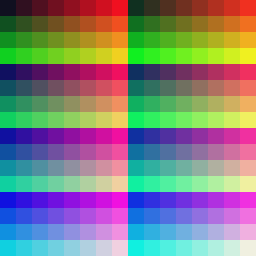

In [10]:
grid_size = 16
grid_pixels = [encoder.rgb_encoder(bytes([value])).as_tuple for value in range(256)]

grid_image = Image.new("RGB", (grid_size, grid_size))
grid_image.putdata(grid_pixels)

output_dir = PROJECT_ROOT / "output"
output_dir.mkdir(exist_ok=True)
grid_path = output_dir / "cube_id_encoding_grid.png"
grid_image.save(grid_path)

print("saved:", grid_path)
grid_image.resize((256, 256), Image.Resampling.NEAREST)

In [11]:
grid_path = PROJECT_ROOT / "output" / "cube_id_encoding_grid.png"
assert grid_path.exists(), f"Run the previous grid image cell first: {grid_path}"

with Image.open(grid_path) as image:
    rgb_image = image.convert("RGB")
    rgb_pixels = tuple(RGB.from_tuple(pixel) for pixel in rgb_image.getdata())

decoded_grid = encoder.rgb_decoder(rgb_pixels)
expected_grid = bytes(range(256))
assert decoded_grid == expected_grid

print("grid image:", grid_path)
print("Decoded grid byte count:", len(decoded_grid))
print("First 16 decoded bytes:", decoded_grid[:16].hex())


Decoded grid byte count: 256
First 16 decoded bytes: 000102030405060708090a0b0c0d0e0f


## Encode a short payload image

payload: b'HASH'
decoded: b'HASH'
saved: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_payload_HASH.png


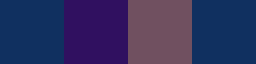

In [12]:
payload = b"HASH"
encoded_payload = encoder.rgb_encoder(payload)
payload_pixels = encoded_payload if isinstance(encoded_payload, tuple) else (encoded_payload,)

payload_image = Image.new("RGB", (len(payload_pixels), 1))
payload_image.putdata([pixel.as_tuple for pixel in payload_pixels])

payload_path = output_dir / "cube_id_payload_HASH.png"
payload_image.save(payload_path)

decoded_payload = encoder.rgb_decoder(payload_pixels)
assert decoded_payload == payload

print("payload:", payload)
print("decoded:", decoded_payload)
print("saved:", payload_path)
payload_image.resize((len(payload_pixels) * 64, 64), Image.Resampling.NEAREST)